In [1]:
import torch
import cv2
from ultralytics import YOLO

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")

model = YOLO("yolov8s.pt")
print("Model loaded successfully")

PyTorch version: 2.8.0
GPU available:   False
Model loaded successfully


In [2]:
# test cell - technically is optional
import urllib.request

urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "test_image.jpg")

results = model("test_image.jpg")
result  = results[0]

print("Quick test — objects found:")
for box in result.boxes:
    class_name = result.names[int(box.cls)]
    confidence = round(float(box.conf) * 100, 1)
    print(f"  - {class_name}: {confidence}%")


image 1/1 /Users/amulyaalaulkar/COM3025-CW/notebooks/test_image.jpg: 640x480 4 persons, 1 bus, 98.1ms
Speed: 1.9ms preprocess, 98.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Quick test — objects found:
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%


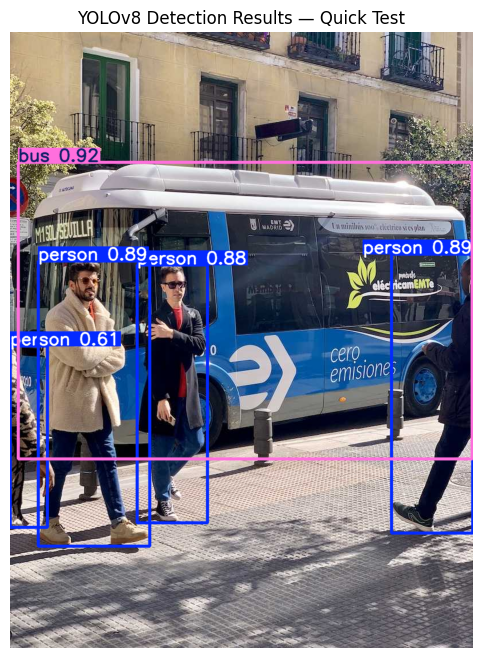

In [3]:
import matplotlib.pyplot as plt

annotated_image     = result.plot()
annotated_image_rgb = annotated_image[:, :, ::-1]  # fix BGR to RGB for display

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis("off")
plt.title("YOLOv8 Detection Results — Quick Test")
plt.show()

In [4]:
CONFIDENCE_THRESHOLD = 0.5

print(f"Detections above {CONFIDENCE_THRESHOLD * 100}% confidence:")
print("-" * 40)

kept    = 0
removed = 0

for box in result.boxes:
    confidence = float(box.conf)
    class_name = result.names[int(box.cls)]

    if confidence < CONFIDENCE_THRESHOLD:
        removed += 1
        continue

    print(f"  - {class_name}: {round(confidence * 100, 1)}%")
    kept += 1

print("-" * 40)
print(f"Kept: {kept} detections ")
print(f"Removed: {removed} low-confidence detections")

Detections above 50.0% confidence:
----------------------------------------
  - bus: 92.1%
  - person: 89.3%
  - person: 88.7%
  - person: 87.8%
  - person: 61.1%
----------------------------------------
Kept: 5 detections 
Removed: 0 low-confidence detections


In [5]:
import os

output_path = "../data/detection_result.jpg"
annotated_save = result.plot()
cv2.imwrite(output_path, annotated_save)

print(f"Saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Saved to: ../data/detection_result.jpg
File size: 361856 bytes


In [6]:
def run_detection(image_path, confidence=0.5, save_result=True):
    results          = model(image_path, conf=confidence, verbose=False)
    result           = results[0]
    detected_objects = [result.names[int(b.cls)] for b in result.boxes]
    annotated_image  = result.plot()
    result_path      = None

    if save_result:
        result_path = image_path.replace(".jpg", "_detected.jpg")
        cv2.imwrite(result_path, annotated_image)

    return detected_objects, annotated_image, result_path


# Quick test of the function
import os
if os.path.exists("test_image.jpg"):
    objects, image, saved = run_detection("test_image.jpg")
    print("run_detection() works correctly")
    print(f"Detected: {objects}")
else:
    print("run_detection() defined — run Cell 3 first to test it")

run_detection() works correctly
Detected: ['bus', 'person', 'person', 'person', 'person']


In [7]:
# Spatial description helper
# Adds position and distance information to each detection.
# Uses bounding box coordinates from YOLO — no extra model needed.
def get_spatial_description(box, image_width, image_height):

    # Get bounding box coordinates
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    # Find the centre point of the box
    box_centre_x = (x1 + x2) / 2
    box_width    = x2 - x1
    box_height   = y2 - y1

    # Work out left / centre / right
    left_boundary   = image_width * 0.33
    right_boundary  = image_width * 0.66

    if box_centre_x < left_boundary:
        position = "on the left"
    elif box_centre_x > right_boundary:
        position = "on the right"
    else:
        position = "in the centre"

    # Work out close / mid-range / far based on how much of the image the box covers
    box_area   = box_width * box_height
    image_area = image_width * image_height
    size_ratio = box_area / image_area

    if size_ratio > 0.40:
        distance = "close up"
    elif size_ratio > 0.10:
        distance = "mid-range"
    else:
        distance = "far away"

    return f"{position}, {distance}"


#Same as run_detection() but adds spatial descriptions to each object.
def run_detection_with_spatial(image_path, confidence=0.5):


    from PIL import Image as PILImage

    img          = PILImage.open(image_path)
    image_width  = img.width
    image_height = img.height

    results    = model(image_path, conf=confidence, verbose=False)
    result     = results[0]
    annotated  = result.plot()

    # Build descriptions with spatial info
    descriptions = []
    for box in result.boxes:
        class_name = result.names[int(box.cls)]
        spatial    = get_spatial_description(box, image_width, image_height)
        descriptions.append(f"{class_name} {spatial}")

    return descriptions, annotated


#  test
import os
if os.path.exists("test_image.jpg"):
    descriptions, annotated = run_detection_with_spatial("test_image.jpg")
    print("Spatial detection test:")
    for d in descriptions:
        print(f"  - {d}")
else:
    print("run_detection_with_spatial() defined — run Cell 2 first to test it")

Spatial detection test:
  - bus in the centre, close up
  - person on the right, far away
  - person on the left, mid-range
  - person in the centre, far away
  - person on the left, far away


In [8]:
# VIDEO MODE WITH TEMPORAL CONSISTENCY
# Continuously captures frames from the webcam and announces objects.
# Only speaks when something NEW appears, disappears, or gets significantly closer.
# Designed to work like an assistive tool for visually impaired users.

# INTEGRATION NOTE FOR PERSON 2:
# When Person 2's TTS is ready, replace the speak() function below with theirs.
# Currently uses pyttsx3 (offline TTS) as a placeholder.

import cv2
import time
import pyttsx3
from PIL import Image as PILImage
import numpy as np

# TEMPORARY TTS Setup
# ONLY THING PERSON 2 NEEDS TO REPLACE

def speak(text):
    engine = pyttsx3.init()
    engine.setProperty('rate', 150)   # speaking speed — 150 words per minute
    engine.setProperty('volume', 1.0) # full volume
    engine.say(text)
    engine.runAndWait()


# Temporal consistency helpers - lets track whether the same type of object is still in roughly the same position between frames

def get_object_key(description):
    parts = description.split()
    obj   = parts[0]  # e.g. 'person'

    if "left" in description:
        zone = "left"
    elif "right" in description:
        zone = "right"
    else:
        zone = "centre"

    return f"{obj}_{zone}"


def get_distance(description):
    if "close up" in description:
        return "close up"
    elif "mid-range" in description:
        return "mid-range"
    else:
        return "far away"

# Compares two sets of descriptions (previous frame vs current frame).
def compare_frames(previous, current):

    prev_keys    = {get_object_key(d): d for d in previous}
    curr_keys    = {get_object_key(d): d for d in current}

    distance_order = {"far away": 0, "mid-range": 1, "close up": 2}

    new_objects    = []
    gone_objects   = []
    closer_objects = []

    # Find new objects — in current frame but not in previous
    for key, desc in curr_keys.items():
        if key not in prev_keys:
            new_objects.append(desc)

    # Find gone objects — in previous frame but not in current
    for key, desc in prev_keys.items():
        if key not in curr_keys:
            gone_objects.append(desc)

    # Find objects that got closer
    for key, curr_desc in curr_keys.items():
        if key in prev_keys:
            prev_dist = distance_order[get_distance(prev_keys[key])]
            curr_dist = distance_order[get_distance(curr_desc)]
            if curr_dist > prev_dist:  # higher number = closer
                closer_objects.append(curr_desc)

    return new_objects, gone_objects, closer_objects


# Priority ordering
# High priority — potential hazards
# Medium priority — obstacles
# Lower priority — objects of interest
PRIORITY = {
    "car": 1, "truck": 1, "bus": 1, "motorcycle": 1, "bicycle": 1,
    "person": 2,
    "chair": 3, "bench": 3, "table": 3, "dining table": 3,
    "couch": 3, "bed": 3, "toilet": 3, "door": 3,
    "dog": 4, "cat": 4, "bottle": 4, "cup": 4,
}

def get_priority(description):
    obj = description.split()[0]
    return PRIORITY.get(obj, 5)  # unknown objects get lowest priority


# Main video loop
# Runs continuous video detection from the webcam.
def run_video_mode(confidence=0.5, frame_interval=0.1):

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Could not open webcam — check camera permissions in System Settings")
        return

    print("Video mode started — press Q in the image window to stop")
    speak("Assistive vision started")

    previous_descriptions = []

    while True:
        # Capture frame
        ret, frame = cap.read()
        if not ret:
            print("Failed to read frame")
            break

        # Save frame temporarily for YOLO to process
        temp_path = "../data/current_frame.jpg"
        cv2.imwrite(temp_path, frame)

        # Get image dimensions for spatial descriptions
        img          = PILImage.open(temp_path)
        image_width  = img.width
        image_height = img.height

        # Run detection with spatial info
        results    = model(temp_path, conf=confidence, verbose=False)
        result     = results[0]
        annotated  = result.plot()

        current_descriptions = []
        for box in result.boxes:
            class_name = result.names[int(box.cls)]
            spatial    = get_spatial_description(box, image_width, image_height)
            current_descriptions.append(f"{class_name} {spatial}")

        # Compare with previous frame
        new_objects, gone_objects, closer_objects = compare_frames(
            previous_descriptions,
            current_descriptions
        )

        # Sort new objects by priority before announcing
        new_objects.sort(key=get_priority)

        # Announce changes
        announcements = []

        for obj in new_objects:
            announcements.append(obj)

        for obj in closer_objects:
            obj_name = obj.split()[0]
            announcements.append(f"{obj_name} getting closer")

        for obj in gone_objects:
            obj_name = obj.split()[0]
            announcements.append(f"{obj_name} gone")

        if announcements:
            full_announcement = ". ".join(announcements)
            print(f"Announcing: {full_announcement}")
            speak(full_announcement)

        # Update previous frame
        previous_descriptions = current_descriptions

        # Show annotated frame in a window
        cv2.imshow("Assistive Vision", annotated)

        # Wait for frame interval or Q key to quit
        if cv2.waitKey(int(frame_interval * 1000)) & 0xFF == ord('q'):
            break

        time.sleep(frame_interval)

    cap.release()
    cv2.destroyAllWindows()
    speak("Assistive vision stopped")
    print("Video mode stopped")

run_video_mode()

Video mode started — press Q in the image window to stop
Announcing: person in the centre, mid-range
Announcing: person gone
Announcing: person in the centre, mid-range
Announcing: bed on the left, mid-range
Announcing: bed gone
Announcing: couch in the centre, close up
Announcing: couch gone
Announcing: person getting closer
Announcing: couch on the left, mid-range
Announcing: couch gone
Announcing: couch in the centre, close up
Video mode stopped


Camera opened — capturing photo in 2 seconds...
Photo captured


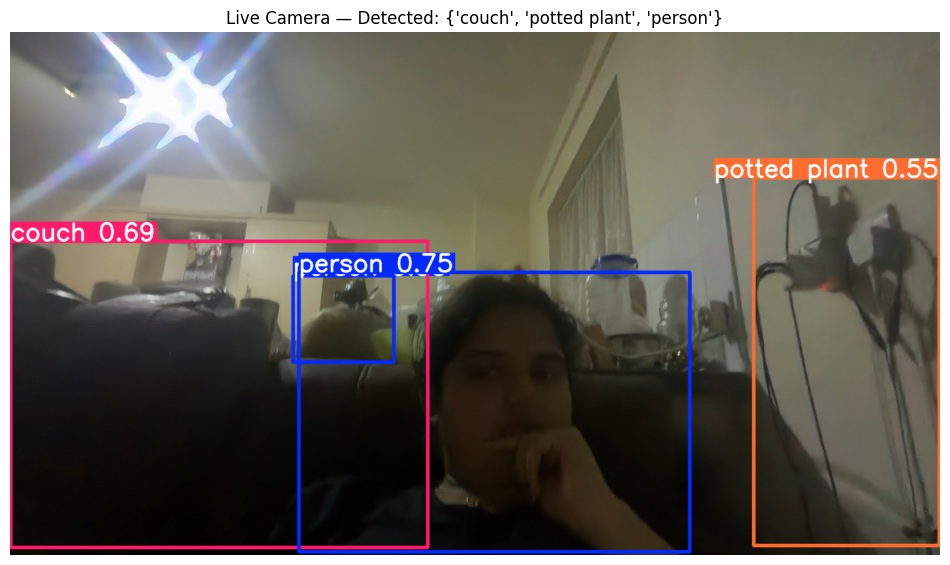

Objects found: ['person', 'couch', 'potted plant', 'person']


In [9]:
import cv2
import matplotlib.pyplot as plt

# Open the webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Could not open webcam — check it is connected and not in use")
else:
    print("Camera opened — capturing photo in 2 seconds...")

    # Let the camera warm up — read a few frames first
    for _ in range(10):
        cap.read()

    # Take the actual photo
    success, frame = cap.read()
    cap.release()  # always release the camera when done

    if not success:
        print("Failed to capture photo — try running the cell again")
    else:
        # Save the captured frame
        cv2.imwrite("../data/camera_capture.jpg", frame)
        print("Photo captured")

        # Run detection
        objects, annotated, saved = run_detection("../data/camera_capture.jpg")

        # Display result
        annotated_rgb = annotated[:, :, ::-1]
        plt.figure(figsize=(12, 8))
        plt.imshow(annotated_rgb)
        plt.axis("off")
        plt.title(f"Live Camera — Detected: {set(objects)}")
        plt.show()

        print(f"Objects found: {objects}")

# basic detection done, COCO dataset detection below


In [10]:
import os
import json
import csv
import time

IMAGE_FOLDER     = "../data/coco_test"
ANNOTATIONS_PATH = "../data/annotations/selected_annotations.json"
RESULTS_FILE     = "../data/detection_results.csv"
CONFIDENCE       = 0.5

# Load ground truth labels
with open(ANNOTATIONS_PATH) as f:
    ground_truth = json.load(f)

selected_images = list(ground_truth.keys())
print(f"Images to process: {len(selected_images)}")
print(f"Sample: {selected_images[:3]}\n")

# Set up CSV
with open(RESULTS_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

print(f"Running detection on {len(selected_images)} images...")
print("-" * 50)

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = model(image_path, conf=CONFIDENCE, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects    = ground_truth[filename]

    with open(RESULTS_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/{len(selected_images)} — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Done. Results saved to {RESULTS_FILE}")

Images to process: 50
Sample: ['000000002592.jpg', '000000003845.jpg', '000000002532.jpg']

Running detection on 50 images...
--------------------------------------------------
  1/50 — 000000002592.jpg — found 1 — GT had 3 — 75.1ms
  2/50 — 000000003845.jpg — found 6 — GT had 6 — 86.9ms
  3/50 — 000000002532.jpg — found 2 — GT had 2 — 91.2ms
  4/50 — 000000003156.jpg — found 2 — GT had 3 — 72.6ms
  5/50 — 000000003661.jpg — found 2 — GT had 3 — 63.2ms
  6/50 — 000000001761.jpg — found 2 — GT had 2 — 68.1ms
  7/50 — 000000005037.jpg — found 4 — GT had 3 — 67.4ms
  8/50 — 000000001532.jpg — found 5 — GT had 2 — 71.0ms
  9/50 — 000000001584.jpg — found 5 — GT had 2 — 102.4ms
  10/50 — 000000002149.jpg — found 4 — GT had 2 — 64.8ms
  11/50 — 000000002923.jpg — found 2 — GT had 2 — 73.1ms
  12/50 — 000000001268.jpg — found 6 — GT had 6 — 68.4ms
  13/50 — 000000004795.jpg — found 2 — GT had 3 — 75.0ms
  14/50 — 000000002006.jpg — found 4 — GT had 4 — 77.3ms
  15/50 — 000000001353.jpg — foun

In [11]:
import csv

total_detections = 0
all_times = []
object_counts = []

with open(RESULTS_FILE) as f:
    reader = csv.DictReader(f)
    for row in reader:
        total_detections += int(row["num_detections"])
        all_times.append(float(row["processing_time_ms"]))
        object_counts.append(int(row["num_detections"]))

total_images = len(object_counts)

print("── Results Summary ──────────────────")
print(f"Images processed:      {total_images}")
print(f"Total detections:      {total_detections}")
print(f"Avg detections/image:  {round(total_detections/total_images, 1)}")
print(f"Avg processing time:   {round(sum(all_times)/len(all_times), 1)}ms")
print(f"Fastest image:         {min(all_times)}ms")
print(f"Slowest image:         {max(all_times)}ms")
print(f"Most objects in one image: {max(object_counts)}")
print(f"Images with 0 detections:  {object_counts.count(0)}")

── Results Summary ──────────────────
Images processed:      50
Total detections:      208
Avg detections/image:  4.2
Avg processing time:   79.0ms
Fastest image:         50.0ms
Slowest image:         130.7ms
Most objects in one image: 15
Images with 0 detections:  1


In [12]:
# baseline comparison
import csv
import time
import os

BASELINE_FILE  = "../data/baseline_results.csv"
baseline_model = YOLO("yolov8n.pt")  # smaller, less accurate model

print("Running baseline detection (YOLOv8n, no confidence filter)...")
print("-" * 50)

with open(BASELINE_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = baseline_model(image_path, conf=0.0, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects    = ground_truth[filename]

    with open(BASELINE_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/50 — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Baseline done. Results saved to {BASELINE_FILE}")

Running baseline detection (YOLOv8n, no confidence filter)...
--------------------------------------------------
  1/50 — 000000002592.jpg — found 300 — GT had 3 — 61.9ms
  2/50 — 000000003845.jpg — found 300 — GT had 6 — 61.4ms
  3/50 — 000000002532.jpg — found 300 — GT had 2 — 79.1ms
  4/50 — 000000003156.jpg — found 300 — GT had 3 — 66.1ms
  5/50 — 000000003661.jpg — found 300 — GT had 3 — 50.5ms
  6/50 — 000000001761.jpg — found 300 — GT had 2 — 73.0ms
  7/50 — 000000005037.jpg — found 300 — GT had 3 — 75.1ms
  8/50 — 000000001532.jpg — found 300 — GT had 2 — 70.2ms
  9/50 — 000000001584.jpg — found 300 — GT had 2 — 107.9ms
  10/50 — 000000002149.jpg — found 300 — GT had 2 — 56.2ms
  11/50 — 000000002923.jpg — found 300 — GT had 2 — 71.1ms
  12/50 — 000000001268.jpg — found 300 — GT had 6 — 61.5ms
  13/50 — 000000004795.jpg — found 300 — GT had 3 — 60.3ms
  14/50 — 000000002006.jpg — found 300 — GT had 4 — 69.4ms
  15/50 — 000000001353.jpg — found 300 — GT had 2 — 59.5ms
  16/50 — 